In [14]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [15]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], errors="ignore", inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")


In [16]:
dataset["hour_sin"] = dataset["timestamp"].apply(lambda x: np.sin(2 * np.pi * x.hour / 24.0))
dataset["hour_cos"] = dataset["timestamp"].apply(lambda x: np.cos(2 * np.pi * x.hour / 24.0))

In [17]:
FEATURE_COLS = ["pm2_5 (μg/m³)", "hour_sin", "hour_cos"]
TARGET_COL = "pm2_5 (μg/m³)"
N_FEATURES = len(FEATURE_COLS)
TARGET_SCALER_IDX = FEATURE_COLS.index(TARGET_COL)


df = dataset[FEATURE_COLS + ["timestamp"]].copy()
df.set_index("timestamp", inplace=True)
df = df.sort_index().asfreq("h") 

INPUT_WINDOW = 24 *3
OUTPUT_WINDOW = 24
BATCH_SIZE = 64

train_raw = df.loc[:"2024-12-31 23:00:00", FEATURE_COLS].copy()
test_raw = df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00", FEATURE_COLS].copy()

scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_raw), columns=FEATURE_COLS, index=train_raw.index)
test_scaled = pd.DataFrame(scaler.transform(test_raw), columns=FEATURE_COLS, index=test_raw.index)


def create_clock_anchored_sequences(df_scaled, feature_cols, target_col, input_w, output_w):
    X, Y = [], []
    feature_matrix = df_scaled[feature_cols].values
    target_vector = df_scaled[target_col].values
    
    for i in range(len(df_scaled) - input_w - output_w + 1):
        X.append(feature_matrix[i : i + input_w, :])
        Y.append(target_vector[i + input_w : i + input_w + output_w])
        
    return np.array(X), np.array(Y)

X_train, y_train = create_clock_anchored_sequences(train_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)
X_test, y_test = create_clock_anchored_sequences(test_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)

In [18]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
import torch
import torch.nn as nn

class TransformerLSTMModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_transformer_layers, hidden_dim, num_lstm_layers, output_dim, seq_len, dropout=0.1):
        super(TransformerLSTMModel, self).__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        x = self.input_projection(src)
        x = x + self.pos_encoder[:, :src.size(1), :]
        x = self.dropout(x)
        transformer_out = self.transformer_encoder(x)
        lstm_out, (hn, cn) = self.lstm(transformer_out)
        out = lstm_out[:, -1, :]
        predictions = self.fc(self.dropout(out))
        return predictions

In [ ]:
import optuna
import torch.optim as optim

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def objective(trial):
    d_model = trial.suggest_categorical("d_model", [32, 64, 128])
    nhead = trial.suggest_categorical("nhead", [2, 4, 8])
    
    if d_model % nhead != 0:
        raise optuna.exceptions.TrialPruned()
        
    num_transformer_layers = trial.suggest_int("num_transformer_layers", 1, 3)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    num_lstm_layers = trial.suggest_int("num_lstm_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    
    trial_model = TransformerLSTMModel(
        input_dim=N_FEATURES, 
        seq_len=INPUT_WINDOW, 
        d_model=d_model, 
        nhead=nhead, 
        num_transformer_layers=num_transformer_layers, 
        hidden_dim=hidden_dim,  
        num_lstm_layers=num_lstm_layers, 
        dropout=dropout, 
        output_dim=OUTPUT_WINDOW
    ).to(DEVICE)
    
    trial_optimizer = optim.Adam(trial_model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    

    epochs = 30 
    
    for epoch in range(epochs):
        trial_model.train()
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)
            
            trial_optimizer.zero_grad(set_to_none=True)
            predictions = trial_model(batch_x)
            loss = criterion(predictions, batch_y)
            loss.backward()
            
            nn.utils.clip_grad_norm_(trial_model.parameters(), max_norm=1.0)
            trial_optimizer.step()
            
        trial_model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(DEVICE, non_blocking=True)
                batch_y = batch_y.to(DEVICE, non_blocking=True)
                val_predictions = trial_model(batch_x)
                val_loss = criterion(val_predictions, batch_y)
                epoch_val_loss += val_loss.item() * batch_x.size(0)
                
        total_val_loss = epoch_val_loss / len(test_loader.dataset)
        
        trial.report(total_val_loss, epoch)

            
    return total_val_loss

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30)

print("\n--- Optimization Complete ---")
print("Best Trial Value (Loss):", study.best_trial.value)
print("Best Hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

[I 2026-06-26 10:39:46,038] A new study created in memory with name: no-name-3d788371-9ad0-462f-b1b1-4ec19e72c11d
[I 2026-06-26 10:42:54,767] Trial 0 finished with value: 0.0034416552944444637 and parameters: {'d_model': 32, 'nhead': 2, 'num_transformer_layers': 1, 'hidden_dim': 128, 'num_lstm_layers': 3, 'dropout': 0.03248054443012004, 'lr': 0.0041425749119555445}. Best is trial 0 with value: 0.0034416552944444637.
[I 2026-06-26 10:46:25,023] Trial 1 finished with value: 0.0039112593909404105 and parameters: {'d_model': 128, 'nhead': 4, 'num_transformer_layers': 3, 'hidden_dim': 64, 'num_lstm_layers': 1, 'dropout': 0.02151784252264539, 'lr': 0.0004571015095453653}. Best is trial 0 with value: 0.0034416552944444637.
[I 2026-06-26 10:48:30,388] Trial 2 finished with value: 0.0028829568380329225 and parameters: {'d_model': 128, 'nhead': 2, 'num_transformer_layers': 1, 'hidden_dim': 32, 'num_lstm_layers': 3, 'dropout': 0.17002260077647838, 'lr': 0.0013681021182105513}. Best is trial 2 wit


--- Optimization Complete ---
Best Trial Value (Loss): 0.00260146969867632
Best Hyperparameters:
  d_model: 32
  nhead: 8
  num_transformer_layers: 1
  hidden_dim: 128
  num_lstm_layers: 2
  dropout: 0.07019528869052584
  lr: 0.00014453859097181612


In [21]:
from pytorch_lightning.callbacks import Callback

class SimpleLossTracker(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss")
        if train_loss is not None:
            self.train_losses.append(train_loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

loss_tracker = SimpleLossTracker()

In [22]:
def inverse_transform_target(scaled_data, scaler, target_idx, n_features):
    flat_data = scaled_data.flatten()
    dummy = np.zeros((len(flat_data), n_features))
    dummy[:, target_idx] = flat_data
    unscaled_dummy = scaler.inverse_transform(dummy)
    return unscaled_dummy[:, target_idx].reshape(scaled_data.shape)

In [23]:
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score as sklearn_r2


best_params = study.best_trial.params
print("\n--- Best Hyperparameters Found ---")
for key, value in best_params.items():
    print(f"  {key}: {value}")

final_model = TransformerLSTMModel(
    input_dim=N_FEATURES, 
    seq_len=INPUT_WINDOW, 
    d_model=best_params["d_model"], 
    nhead=best_params["nhead"], 
    num_transformer_layers=best_params["num_transformer_layers"], 
    hidden_dim=best_params["hidden_dim"],  
    num_lstm_layers=best_params["num_lstm_layers"], 
    dropout=best_params["dropout"], 
    output_dim=OUTPUT_WINDOW
).to(DEVICE)

final_optimizer = optim.Adam(final_model.parameters(), lr=best_params["lr"])
criterion = nn.MSELoss()

hist_train = []
hist_val = []
FINAL_EPOCHS = 60

print(f"\nTraining final optimized model for {FINAL_EPOCHS} epochs...")
for epoch in range(FINAL_EPOCHS):
    final_model.train()
    epoch_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE, non_blocking=True)
        batch_y = batch_y.to(DEVICE, non_blocking=True)

        final_optimizer.zero_grad(set_to_none=True)
        predictions = final_model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        
        nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        final_optimizer.step()
        
        epoch_train_loss += loss.item() * batch_x.size(0)

    total_train_loss = epoch_train_loss / len(train_loader.dataset)
    hist_train.append(total_train_loss)

    final_model.eval()
    epoch_val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)
            
            val_predictions = final_model(batch_x)
            val_loss = criterion(val_predictions, batch_y)
            
            epoch_val_loss += val_loss.item() * batch_x.size(0)
            
    total_val_loss = epoch_val_loss / len(test_loader.dataset)
    hist_val.append(total_val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{FINAL_EPOCHS} | Train Loss (MSE): {total_train_loss:.6f} | Val Loss (MSE): {total_val_loss:.6f}")



--- Best Hyperparameters Found ---
  d_model: 32
  nhead: 8
  num_transformer_layers: 1
  hidden_dim: 128
  num_lstm_layers: 2
  dropout: 0.07019528869052584
  lr: 0.00014453859097181612

Training final optimized model for 60 epochs...
Epoch 01/60 | Train Loss (MSE): 0.004103 | Val Loss (MSE): 0.003383
Epoch 10/60 | Train Loss (MSE): 0.002977 | Val Loss (MSE): 0.002864
Epoch 20/60 | Train Loss (MSE): 0.002776 | Val Loss (MSE): 0.002669
Epoch 30/60 | Train Loss (MSE): 0.002550 | Val Loss (MSE): 0.002870
Epoch 40/60 | Train Loss (MSE): 0.002224 | Val Loss (MSE): 0.003164
Epoch 50/60 | Train Loss (MSE): 0.001746 | Val Loss (MSE): 0.003518
Epoch 60/60 | Train Loss (MSE): 0.001322 | Val Loss (MSE): 0.003449


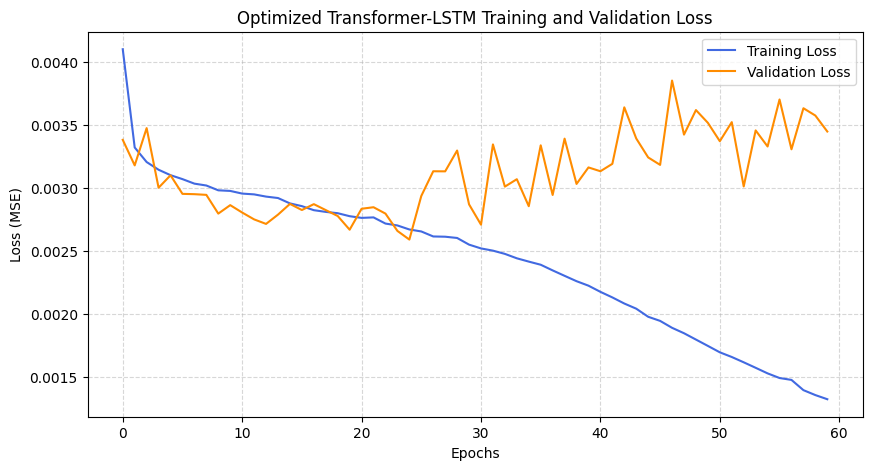

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(hist_train, label='Training Loss', color='royalblue')
plt.plot(hist_val, label='Validation Loss', color='darkorange')
plt.title('Optimized Transformer-LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

In [25]:
final_model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        
        preds = final_model(batch_x).cpu().numpy()
        actuals = batch_y.numpy()
        
        all_predictions.append(preds)
        all_ground_truth.append(actuals)

all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

true_predictions_all = inverse_transform_target(all_predictions, scaler, TARGET_SCALER_IDX, N_FEATURES)
true_ground_truth_all = inverse_transform_target(all_ground_truth, scaler, TARGET_SCALER_IDX, N_FEATURES)

global_mae = mean_absolute_error(true_ground_truth_all.flatten(), true_predictions_all.flatten())
global_rmse = np.sqrt(mean_squared_error(true_ground_truth_all.flatten(), true_predictions_all.flatten()))
global_r2 = sklearn_r2(true_ground_truth_all.flatten(), true_predictions_all.flatten())

ground_truth_mean = np.mean(true_ground_truth_all)
mae_percentage = (global_mae / ground_truth_mean)
rmse_percentage = (global_rmse / ground_truth_mean)

print(f"\n=== Final Transformer-LSTM Benchmark Results ===")
print(f"Global R² Score     : {global_r2:.4f}")
print(f"Global MAE          : {global_mae:.4f} μg/m³")
print(f"Global RMSE         : {global_rmse:.4f} μg/m³")
print(f"MAE% (Normalized)   : {mae_percentage:.2f}")
print(f"RMSE% (Normalized)  : {rmse_percentage:.2f}")


=== Final Transformer-LSTM Benchmark Results ===
Global R² Score     : 0.5344
Global MAE          : 3.0525 μg/m³
Global RMSE         : 4.3989 μg/m³
MAE% (Normalized)   : 0.33
RMSE% (Normalized)  : 0.47


In [26]:
import plotly.graph_objects as go

sample_indices = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
num_samples = len(sample_indices)

fig = go.Figure()
buttons = []

for idx, sample_idx in enumerate(sample_indices):
    # Pull directly from pre-computed, inverted arrays to avoid loop overhead
    true_actual = true_ground_truth_all[sample_idx]
    true_pred = true_predictions_all[sample_idx]
    
    start_timestamp_idx = INPUT_WINDOW + sample_idx
    window_timestamps = df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[
        start_timestamp_idx : start_timestamp_idx + OUTPUT_WINDOW
    ]
    time_labels = [str(t).split()[1][:5] for t in window_timestamps]
    date_str = str(window_timestamps[0]).split()[0]
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_actual,
        mode='lines+markers',
        name=f'Actual PM2.5 ({date_str})',
        line=dict(color='seagreen', width=3),
        visible=(idx == 0)
    ))
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_pred,
        mode='lines+markers',
        name=f'Transformer-LSTM Forecast ({date_str})',
        line=dict(color='darkorange', width=2, dash='dash'),
        visible=(idx == 0)
    ))
    
    visibility_mask = [False] * (num_samples * 2)
    visibility_mask[idx * 2] = True
    visibility_mask[idx * 2 + 1] = True
    
    buttons.append(dict(
        label=f"Horizon: {date_str}",
        method="update",
        args=[
            {"visible": visibility_mask},
            {"title": f"<b>Transformer-LSTM Performance Horizon: {date_str}</b>"} 
        ]
    ))

initial_date_str = str(df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[INPUT_WINDOW]).split()[0]

fig.update_layout(
    title=dict(
        text=f'<b>Transformer-LSTM Performance Horizon: {initial_date_str}</b>',
        x=0.5,
        font=dict(size=16)
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.0,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ],
    xaxis=dict(title='Hour of Day (24h Forecast Horizon)', showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title='PM2.5 Concentration (μg/m³)', showgrid=True, gridcolor='lightgray'),
    template='plotly_white',
    hovermode='x unified',
    height=550,
    width=900,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()